In [2]:
%pylab notebook

Populating the interactive namespace from numpy and matplotlib


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#### Input Gaia files - GRB and TESS data

In [4]:
#TESS DATA - TESS
model = pd.read_csv('model.out.3',delim_whitespace=True,comment='#', names = ['Phase','Magnitude'],usecols=[0,1])

#GAIA data - RED EPOCH
model_gaia_red = pd.read_csv('model.red.gaia.out.3',delim_whitespace=True,comment='#', names = ['Phase','Magnitude_unscaled'],usecols=[0,1])

#GAIA data - GREEN EPOCH
model_gaia_green = pd.read_csv('model.green.gaia.out.3',delim_whitespace=True,comment='#', names = ['Phase','Magnitude_unscaled'],usecols=[0,1])

#GAIA data - BLUE EPOCH
model_gaia_blue = pd.read_csv('model.blue.gaia.out.3',delim_whitespace=True,comment='#', names = ['Phase','Magnitude_unscaled'],usecols=[0,1])

In [5]:
val = model_gaia_red
val['Magnitude'] = (val['Magnitude_unscaled']-val['Magnitude_unscaled'].min())/(val['Magnitude_unscaled'].max()-val['Magnitude_unscaled'].min())

val = model_gaia_green
val['Magnitude'] = (val['Magnitude_unscaled']-val['Magnitude_unscaled'].min())/(val['Magnitude_unscaled'].max()-val['Magnitude_unscaled'].min())

val = model_gaia_blue
val['Magnitude'] = (val['Magnitude_unscaled']-val['Magnitude_unscaled'].min())/(val['Magnitude_unscaled'].max()-val['Magnitude_unscaled'].min())

model['Magnitude'] = (model['Magnitude']-model['Magnitude'].min())/(model['Magnitude'].max()-model['Magnitude'].min())

#### Overplotting model fits - GRB data and Tess data

<IPython.core.display.Javascript object>


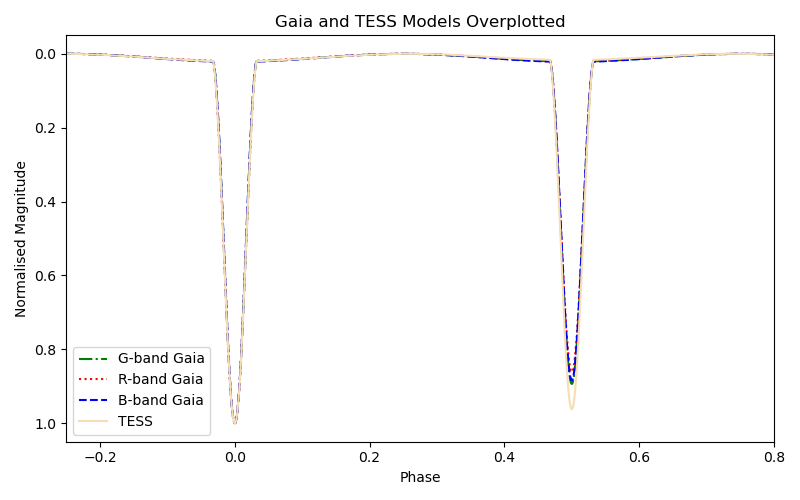

In [6]:
fig, ax = plt.subplots(nrows=1, sharex=True, figsize=(8, 5))
ax.plot(model_gaia_green['Phase'], model_gaia_green['Magnitude'], color='green', label='G-band Gaia',linestyle='dashdot')
ax.plot(model_gaia_green['Phase'] - 1, model_gaia_green['Magnitude'], color='green',linestyle='dashdot')

ax.plot(model_gaia_red['Phase'], model_gaia_red['Magnitude'], color='red', label='R-band Gaia',linestyle='dotted')
ax.plot(model_gaia_red['Phase'] - 1, model_gaia_red['Magnitude'], color='red',linestyle='dotted')

ax.plot(model_gaia_blue['Phase'], model_gaia_blue['Magnitude'], color='blue', label='B-band Gaia',linestyle='dashed')
ax.plot(model_gaia_blue['Phase'] - 1, model_gaia_blue['Magnitude'], color='blue',linestyle='dashed')

ax.plot(model['Phase'], model['Magnitude'], color='wheat', label='TESS',linestyle='-')
ax.plot(model['Phase'] - 1, model['Magnitude'], color='wheat',linestyle='-')

ax.set_xlim(-0.25,0.8)

ax.yaxis.set_inverted(True) #because it's a magnitude

ax.set_xlabel('Phase')
ax.set_ylabel('Normalised Magnitude')
ax.set_title('Gaia and TESS Models Overplotted')
ax.legend()

fig.tight_layout()
plt.show()